# 02 Kpis Retention

Flood-It! retention and churn project. Run cells top to bottom.

### Imports and settings

In [1]:
import pandas as pd                                                   # tables
import numpy as np                                                    # maths
import matplotlib.pyplot as plt                                       # charts
import seaborn as sns                                                 # nicer charts
from scipy import stats                                               # chi-square test
from statsmodels.stats.proportion import proportion_confint, proportions_ztest   # confidence intervals and z-test for rates
from pathlib import Path                                              # file paths

sns.set_theme(style="whitegrid")                                      # clean chart style
pd.set_option("display.max_columns", None)                            # never hide columns
pd.set_option("display.width", 200)                                   # wide printing

### Paths and data

In [2]:
ROOT = Path.cwd()                                                     # folder the notebook runs in
if ROOT.name == "notebooks":                                          # if inside notebooks/...
    ROOT = ROOT.parent                                                # ...go up to the project root
DATA = ROOT / "data" / "processed"                                    # exported BigQuery tables
FIG = ROOT / "reports" / "figures"                                    # charts folder
FIG.mkdir(parents=True, exist_ok=True)                                # create it if needed
kpi = pd.read_csv(DATA / "kpi_daily.csv", parse_dates=["day"]).sort_values("day")                   # daily KPIs
summary = pd.read_csv(DATA / "retention_summary.csv").sort_values("day_number")                     # D1/D3/D7/D14/D30
cohorts = pd.read_csv(DATA / "retention_cohorts_weekly.csv", parse_dates=["cohort_week"])           # cohort x day table
milestones = pd.read_csv(DATA / "retention_by_milestone.csv").sort_values("furthest_milestone_day0")  # day-0 progress groups
funnel = pd.read_csv(DATA / "first_day_funnel.csv").sort_values("step_order")                       # funnel steps
segments = pd.read_csv(DATA / "retention_by_segment.csv")                                           # platform x country
print(kpi.shape, summary.shape, cohorts.shape, milestones.shape, funnel.shape, segments.shape)      # confirm everything loaded

(114, 13) (5, 5) (426, 5) (4, 6) (6, 3) (22, 6)


### KPI overview

In [3]:
full = kpi[kpi["has_full_28d_window"]]                                 # days where 28-day MAU is complete
overview = pd.Series({
    "first_day": kpi["day"].min().date(),                              # start of data
    "last_day": kpi["day"].max().date(),                               # end of data
    "avg_dau": round(kpi["dau"].mean(), 1),                            # average daily active players
    "avg_mau_28d (full windows)": round(full["mau_28d"].mean(), 1),    # average 28-day actives
    "avg_stickiness (full windows)": round(full["stickiness_dau_mau"].mean(), 4),   # DAU / MAU
    "avg_sessions_per_dau": round(kpi["sessions_per_dau"].mean(), 3),  # sessions per active player
    "avg_minutes_per_dau": round(kpi["minutes_per_dau"].mean(), 3),    # engaged minutes per active player
    "avg_ad_rewards_per_dau": round(kpi["ad_rewards_per_dau"].mean(), 4),   # rewarded ads per active player
})
print(overview.to_string())                                            # print as a neat list

first_day                        2018-06-12
last_day                         2018-10-03
avg_dau                               471.4
avg_mau_28d (full windows)           4629.4
avg_stickiness (full windows)         0.101
avg_sessions_per_dau                  1.549
avg_minutes_per_dau                  12.217
avg_ad_rewards_per_dau               0.0352


### Chart: DAU with a 7-day average, and stickiness

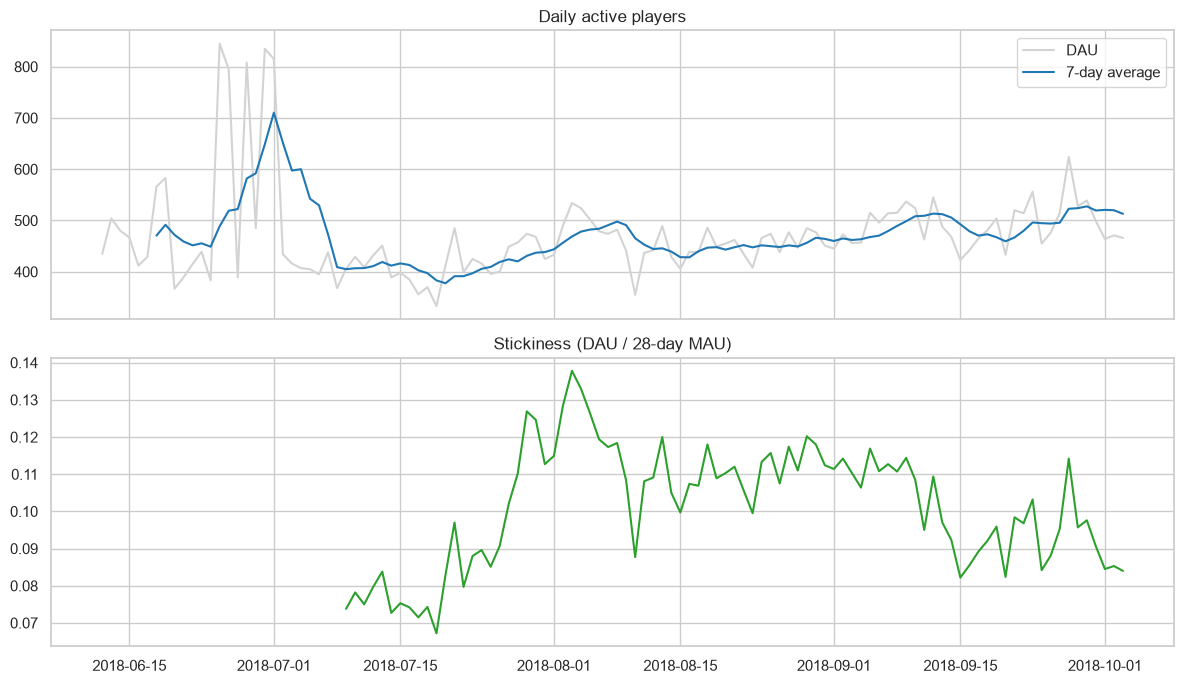

In [4]:
kpi["dau_7d_avg"] = kpi["dau"].rolling(7, min_periods=7).mean()        # smooth out weekday/weekend swings
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)          # two stacked charts sharing the date axis
axes[0].plot(kpi["day"], kpi["dau"], color="lightgray", label="DAU")  # raw daily values
axes[0].plot(kpi["day"], kpi["dau_7d_avg"], color="tab:blue", label="7-day average")   # smoothed line
axes[0].set_title("Daily active players")                             # title
axes[0].legend()                                                       # legend
axes[1].plot(full["day"], full["stickiness_dau_mau"], color="tab:green")   # stickiness only where MAU is complete
axes[1].set_title("Stickiness (DAU / 28-day MAU)")                    # title
fig.tight_layout()                                                     # tidy spacing
fig.savefig(FIG / "01_dau_stickiness.png", dpi=150)                   # save
plt.show()                                                             # display

### Retention summary with 95% Wilson confidence intervals

In [5]:
ci_low, ci_high = proportion_confint(summary["retained_players"], summary["eligible_players"], alpha=0.05, method="wilson")  # interval for each rate
summary["ci_low_pct"] = (100 * ci_low).round(2)                        # lower bound in percent
summary["ci_high_pct"] = (100 * ci_high).round(2)                      # upper bound in percent
print(summary.to_string(index=False))                                  # show the table

retention_day  day_number  eligible_players  retained_players  retention_pct  ci_low_pct  ci_high_pct
           D1           1             11645              1552          13.33       12.72        13.96
           D3           3             11479               880           7.67        7.19         8.17
           D7           7             11066               558           5.04        4.65         5.47
          D14          14             10360               433           4.18        3.81         4.58
          D30          30              8281               216           2.61        2.29         2.97


### Chart: average retention curve from day 0 to day 30

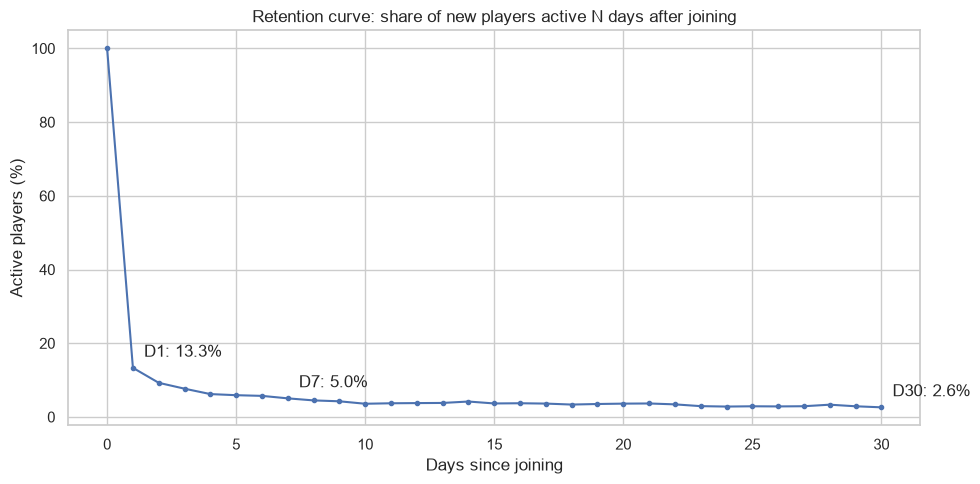

In [6]:
curve = cohorts.groupby("day_number")[["active_players", "eligible_players"]].sum().reset_index()   # add up all cohort weeks
curve["retention_pct"] = 100 * curve["active_players"] / curve["eligible_players"]                  # weighted average retention
fig, ax = plt.subplots(figsize=(10, 5))                                # empty chart
ax.plot(curve["day_number"], curve["retention_pct"], marker="o", markersize=3)   # the curve
for day in [1, 7, 30]:                                                 # label three key points
    row = curve[curve["day_number"] == day]                            # find that day
    if len(row) == 1:                                                  # only if the day exists in the data
        ax.annotate(f"D{day}: {row['retention_pct'].iloc[0]:.1f}%", (day, row["retention_pct"].iloc[0]), textcoords="offset points", xytext=(8, 8))   # text label
ax.set_title("Retention curve: share of new players active N days after joining")   # title
ax.set_xlabel("Days since joining")                                    # x label
ax.set_ylabel("Active players (%)")                                    # y label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "02_retention_curve.png", dpi=150)                   # save
plt.show()                                                             # display

### Chart: weekly cohort retention heatmap

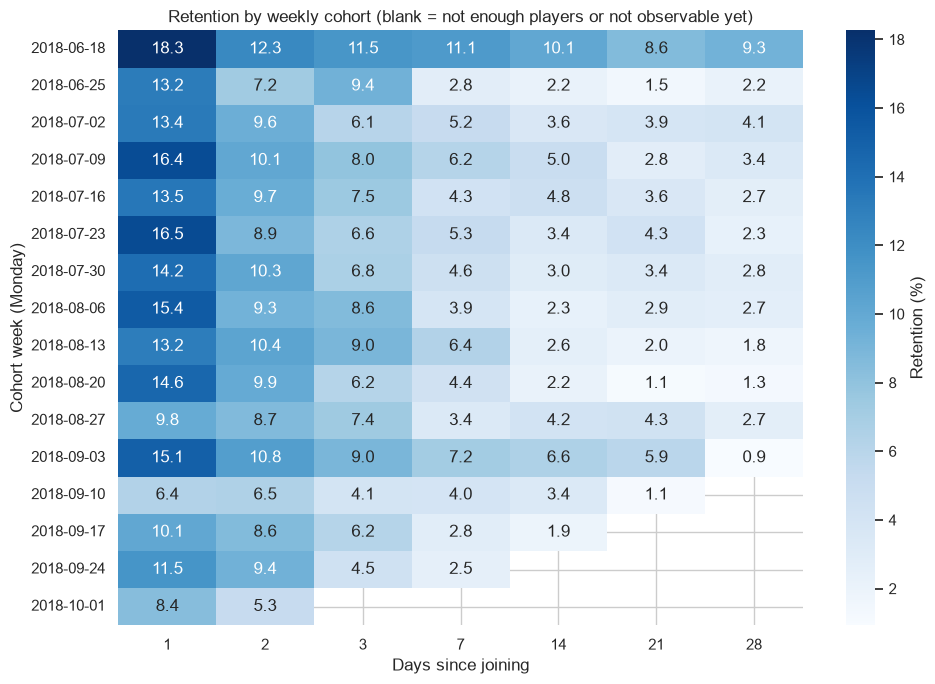

In [7]:
show_days = [1, 2, 3, 7, 14, 21, 28]                                   # columns to show
heat = cohorts[cohorts["day_number"].isin(show_days)].copy()           # keep those days only
heat.loc[heat["eligible_players"] < 50, "retention_pct"] = np.nan      # hide tiny groups (too noisy to read)
pivot = heat.pivot(index="cohort_week", columns="day_number", values="retention_pct")   # rows = weeks, columns = days
pivot.index = pivot.index.strftime("%Y-%m-%d")                         # readable week labels
fig, ax = plt.subplots(figsize=(10, 7))                                # empty chart
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Retention (%)"}, ax=ax)   # coloured grid
ax.set_title("Retention by weekly cohort (blank = not enough players or not observable yet)")   # title
ax.set_xlabel("Days since joining")                                    # x label
ax.set_ylabel("Cohort week (Monday)")                                  # y label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "03_cohort_heatmap.png", dpi=150)                    # save
plt.show()                                                             # display

### Chart: first-day funnel

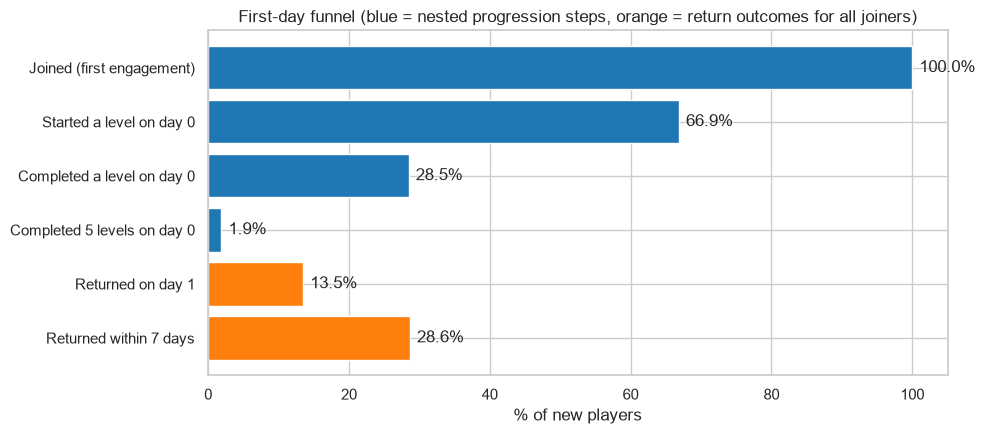

 step_order                        step  players  pct_of_joined
          1   Joined (first engagement)    11066     100.000000
          2    Started a level on day 0     7398      66.853425
          3  Completed a level on day 0     3151      28.474607
          4 Completed 5 levels on day 0      209       1.888668
          5           Returned on day 1     1493      13.491777
          6      Returned within 7 days     3170      28.646304


In [8]:
funnel["pct_of_joined"] = 100 * funnel["players"] / funnel["players"].iloc[0]   # every step as % of all joiners
fig, ax = plt.subplots(figsize=(10, 4.5))                              # empty chart
ax.barh(funnel["step"], funnel["pct_of_joined"], color=["tab:blue"] * 4 + ["tab:orange"] * 2)   # blue = progression, orange = retention
ax.invert_yaxis()                                                      # first step at the top
for i, value in enumerate(funnel["pct_of_joined"]):                    # loop to write each percentage
    ax.text(value + 1, i, f"{value:.1f}%", va="center")               # label next to the bar
ax.set_title("First-day funnel (blue = nested progression steps, orange = return outcomes for all joiners)")   # title
ax.set_xlabel("% of new players")                                      # x label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "04_first_day_funnel.png", dpi=150)                  # save
plt.show()                                                             # display
print(funnel.to_string(index=False))                                   # table version

### Retention by day-0 milestone, with confidence intervals and a chi-square test

     furthest_milestone_day0  players  retained_d1_players  returned_players  d1_retention_pct  returned_within_7d_pct  ci_low_pct  ci_high_pct
1) Engaged, no level started     3058                  268               620              8.76                   20.27   18.887423    21.736544
     2) Started a level only     4020                  429              1002             10.67                   24.93   23.612517    26.286106
        3) Completed a level     2946                  497              1065             16.87                   36.15   34.434909    37.902587
       4) Completed 5 levels     1042                  299               483             28.69                   46.35   43.344307    49.388818
Chi-square = 373.1, dof = 3, p = 1.50e-80


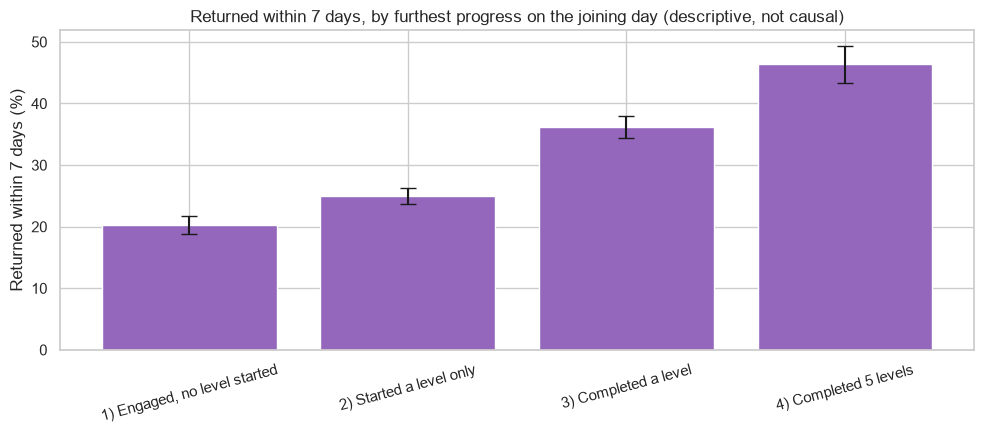

In [9]:
milestones["returned_players"] = milestones["returned_players"].astype(int)   # raw counts come straight from the SQL view, no rounding round-trip
low, high = proportion_confint(milestones["returned_players"], milestones["players"], method="wilson")   # 95% CI per group
milestones["ci_low_pct"] = 100 * low                                   # lower bound
milestones["ci_high_pct"] = 100 * high                                 # upper bound
table = np.column_stack([milestones["returned_players"], milestones["players"] - milestones["returned_players"]])   # returned vs not
chi2, p_value, dof, expected = stats.chi2_contingency(table)           # are return rates different across milestones?
print(milestones.to_string(index=False))                               # table
print(f"Chi-square = {chi2:.1f}, dof = {dof}, p = {p_value:.2e}")      # test result
fig, ax = plt.subplots(figsize=(10, 4.5))                              # empty chart
errors = [milestones["returned_within_7d_pct"] - milestones["ci_low_pct"], milestones["ci_high_pct"] - milestones["returned_within_7d_pct"]]   # CI distances
ax.bar(milestones["furthest_milestone_day0"], milestones["returned_within_7d_pct"], yerr=errors, capsize=6, color="tab:purple")   # bars with CI
ax.set_title("Returned within 7 days, by furthest progress on the joining day (descriptive, not causal)")   # title
ax.set_ylabel("Returned within 7 days (%)")                            # y label
plt.setp(ax.get_xticklabels(), rotation=15)                            # tilt labels
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "05_retention_by_milestone.png", dpi=150)            # save
plt.show()                                                             # display

### Platform comparison: two-proportion z-test and 95% CI for the difference

In [10]:
platform = segments.groupby("platform")[["players", "returned_players"]].sum()   # add up countries within each platform
platform["returned_pct"] = 100 * platform["returned_players"] / platform["players"]   # return rate
print(platform.round(2))                                               # show table
if {"ANDROID", "IOS"}.issubset(platform.index):                        # only run the test if both platforms exist
    counts = platform.loc[["IOS", "ANDROID"], "returned_players"].to_numpy()   # [iOS, Android] returned players
    nobs = platform.loc[["IOS", "ANDROID"], "players"].to_numpy()      # [iOS, Android] players
    z_stat, p_val = proportions_ztest(counts, nobs)                    # two-sided z-test
    p1, p2 = counts / nobs                                             # the two rates
    se = np.sqrt(p1 * (1 - p1) / nobs[0] + p2 * (1 - p2) / nobs[1])    # unpooled standard error
    print(f"iOS minus Android: {100 * (p1 - p2):.2f} pp, 95% CI ({100 * (p1 - p2 - 1.96 * se):.2f}, {100 * (p1 - p2 + 1.96 * se):.2f}) pp, z = {z_stat:.2f}, p = {p_val:.4f}")

          players  returned_players  returned_pct
platform                                         
ANDROID      5521              1616         29.27
IOS          5545              1554         28.03
iOS minus Android: -1.24 pp, 95% CI (-2.93, 0.44) pp, z = -1.45, p = 0.1476


### Chart: return rate by country group

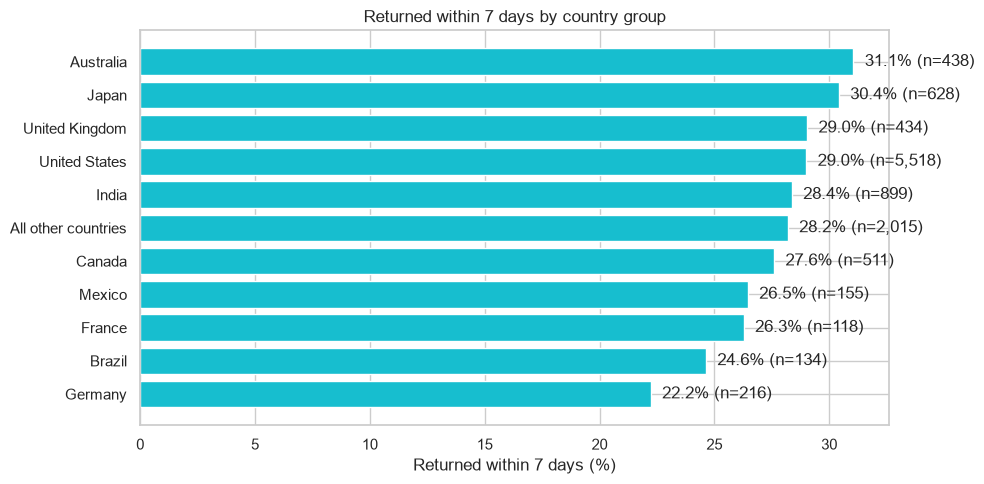

In [11]:
country = segments.groupby("country_group")[["players", "returned_players"]].sum()   # add up platforms
country["returned_pct"] = 100 * country["returned_players"] / country["players"]      # rate
country = country.sort_values("returned_pct")                          # order for the chart
fig, ax = plt.subplots(figsize=(10, 5))                                # empty chart
ax.barh(country.index, country["returned_pct"], color="tab:cyan")      # horizontal bars
for i, (pct, n) in enumerate(zip(country["returned_pct"], country["players"])):   # loop to label bars
    ax.text(pct + 0.5, i, f"{pct:.1f}% (n={n:,})", va="center")       # rate and group size
ax.set_title("Returned within 7 days by country group")                # title
ax.set_xlabel("Returned within 7 days (%)")                            # x label
fig.tight_layout()                                                     # tidy
fig.savefig(FIG / "06_retention_by_country.png", dpi=150)              # save
plt.show()                                                             # display